In [2]:
## 1. Date Feature Engineering

import pandas as pd

df = pd.read_csv('E:/Bitsom/Assignment/Machine Learning/data/q3_retail_promotions.csv')

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month end feature
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [3]:
## 2. Temporal Train-Test Split
# Sort by date
df = df.sort_values(by='transaction_date')

# Split
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

print("Train size:", train.shape)
print("Test size:", test.shape)

Train size: (960, 13)
Test size: (240, 13)


In [4]:
## 3. Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Features and target
target = 'items_sold'

X_train = train.drop(columns=[target, 'transaction_date'])
y_train = train[target]

X_test = test.drop(columns=[target, 'transaction_date'])
y_test = test[target]

# Column groups
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

In [5]:
## 4. Model Training and Evaluation

## Linear Regression Pipeline

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

## Random Forest Pipeline

from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

## Evaluation Metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")


Linear Regression
RMSE: 27.12145116489062
MAE: 21.052926674588388

Random Forest
RMSE: 31.658897860633115
MAE: 24.904708333333335


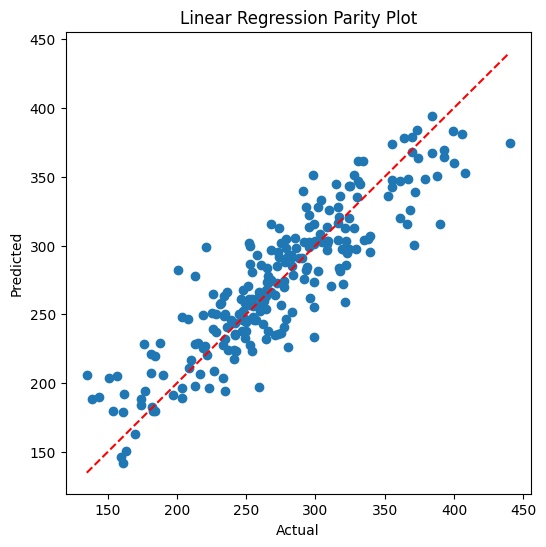

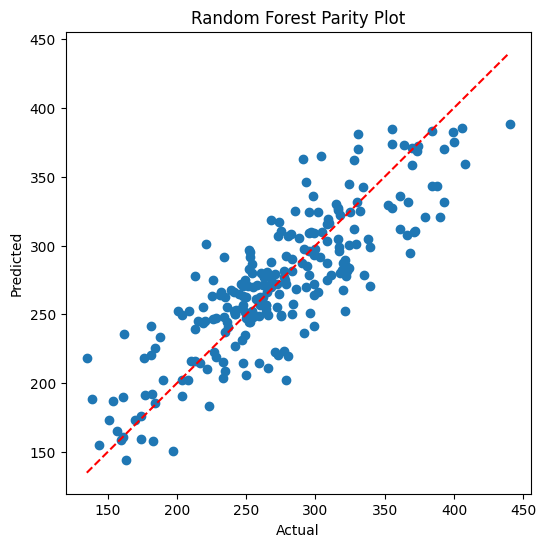

In [6]:
## Parity Plot

import matplotlib.pyplot as plt

def parity_plot(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.show()

parity_plot(y_test, y_pred_lr, "Linear Regression Parity Plot")
parity_plot(y_test, y_pred_rf, "Random Forest Parity Plot")

## Model Evaluation and Comparison:
### Key Observations:

- Linear Regression outperforms Random Forest across both RMSE and MAE.
- Lower RMSE indicates that Linear Regression has smaller prediction errors overall.
- Lower MAE confirms more consistent prediction accuracy.

### Parity Plot Analysis:

- The Linear Regression plot shows predictions closely aligned with the diagonal line, indicating strong predictive performance.
- The Random Forest plot shows greater dispersion from the diagonal, suggesting higher prediction error and less consistency.

### Interpretation:

This result suggests that the relationship between features and items_sold is relatively **linear**, allowing Linear Regression to perform effectively.

Random Forest, being a more complex model, may be:
- Overfitting to noise
- Not benefiting from strong non-linear patterns in the data

### Conclusion:

Linear Regression is the better model for this problem, as it provides:
- Lower error metrics (RMSE and MAE)
- More stable and consistent predictions

This highlights that simpler models can outperform complex ones when the underlying data relationships are linear.